In [ ]:
import numpy as np
import pandas as pd
from torch import nn
import torch
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import random

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report

# machine-learning
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

from scipy import stats

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import scipy as sci
import seaborn as sns
import re
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
import random

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tensorflow as tf

from keras.callbacks import ModelCheckpoint
from keras.models import load_model

import tensorflow as tf
from tensorflow import keras
from keras import layers

In [ ]:
ship_beam = 48

In [ ]:
data = pd.read_excel('KIMOLOS analysis from DD till 9-1-2024.xlsx', sheet_name=0)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34609 entries, 0 to 34608
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   UTC Time                               34609 non-null  object 
 1   M/E RPM                                34609 non-null  float64
 2   Voyage No                              34609 non-null  int64  
 3   Loading Status                         34609 non-null  object 
 4   Cargo Weight (tons)                    34609 non-null  int64  
 5   SOW (knots)                            34609 non-null  float64
 6   Slip SOW (%)                           34609 non-null  float64
 7   DRAFT MP                               34609 non-null  int64  
 8   DRAFT MS                               34609 non-null  float64
 9   Trim (m)                               34609 non-null  float64
 10  Depth (m)                              34609 non-null  int64  
 11  Wi

In [ ]:
data['UTC Time'] = pd.to_datetime(data['UTC Time'])
data['Mean Draft (m)'] = (data['DRAFT MP'] + data['DRAFT MS'])/2
data['Course Drift (deg)'] = data['Gyro Heading (deg)'] - data['GPS Course (deg)']

wanted_col = data.select_dtypes(include=[float]).columns

for col in wanted_col:
  data = data.loc[(np.abs(stats.zscore(data[col])) < 2.7)]

data = data.loc[data["Voyage Status"].str.contains('Sailing')\
                          & (data["M/E FLOW METER GROUP ALARM"] != 1)\
                          & (data["M/E RPM"] > 0)\
                          & (data["M/E Brake Power (KW)"] > 2000)\
                          #& (data["Depth (m)"] > 70)\
                          & (data["SOW (knots)"] >= 5)\
                          & (data["SOG (knots)"] >= 5)\
                          & (data["M/E FOC (tons/day)"] > 0)\
                          ]

#y = data.loc[:, ['M/E FOC (tons/day)', 'M/E Brake Power (KW)', 'M/E RPM']] # .apply(lambda iterator: ((iterator - iterator.mean())/iterator.std()).round(2))

####
"""
foc_mean = np.mean(y['M/E FOC (tons/day)'])
power_mean = np.mean(y['M/E Brake Power (KW)'])
rpm_mean = np.mean(y['M/E RPM'])

foc_std = np.std(y['M/E FOC (tons/day)'])
power_std = np.std(y['M/E Brake Power (KW)'])
rpm_std = np.std(y['M/E RPM'])
"""
x = data.drop(['UTC Time', 'Voyage Status', 'M/E FLOW METER GROUP ALARM', \
                   'Loading Status', 'M/E FOC (tons/day)', 'M/E Brake Power (KW)', \
               'Voyage No', 'M/E Fuel Type', 'Steady/Transient Operation'], axis=1)#.apply(lambda iterator: ((iterator - iterator.mean())/iterator.std()))
y = data.loc[:, ['M/E Brake Power (KW)']]

"""
y['M/E FOC (tons/day)'] = (y['M/E FOC (tons/day)'] - foc_mean)/foc_std
y['M/E Brake Power (KW)'] = (y['M/E Brake Power (KW)'] - power_mean)/power_std
y['M/E RPM'] = (y['M/E RPM'] - rpm_mean)/rpm_std
"""

"\ny['M/E FOC (tons/day)'] = (y['M/E FOC (tons/day)'] - foc_mean)/foc_std\ny['M/E Brake Power (KW)'] = (y['M/E Brake Power (KW)'] - power_mean)/power_std\ny['M/E RPM'] = (y['M/E RPM'] - rpm_mean)/rpm_std\n"

#**XGBoost**

In [ ]:
import xgboost as xgb

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [ ]:
dtrain_reg = xgb.DMatrix(X_train,y_train, enable_categorical=False)
dtest_reg = xgb.DMatrix(X_test, y_test, enable_categorical=False)
params = {"objective": "reg:squarederror", "tree_method": "hist"}
evals = [(dtest_reg, "validation"), (dtrain_reg, "train")]
model = xgb.train(params=params, dtrain=dtrain_reg, num_boost_round=10000, evals = evals, verbose_eval=500, early_stopping_rounds=30)

[0]	validation-rmse:1730.81484	train-rmse:1740.03419
[500]	validation-rmse:120.97351	train-rmse:5.48392
[1000]	validation-rmse:120.86846	train-rmse:0.83437
[1500]	validation-rmse:120.86081	train-rmse:0.13545
[2000]	validation-rmse:120.86079	train-rmse:0.02218
[2500]	validation-rmse:120.86095	train-rmse:0.00381
[2803]	validation-rmse:120.86093	train-rmse:0.00187


#**Gaussian Process**

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
kernel = DotProduct() + WhiteKernel()

In [ ]:
data = data.sample(n = 1000)

data['UTC Time'] = pd.to_datetime(data['UTC Time'])
data['Mean Draft (m)'] = (data['DRAFT MP'] + data['DRAFT MS'])/2
data['Course Drift (deg)'] = data['Gyro Heading (deg)'] - data['GPS Course (deg)']

wanted_col = data.select_dtypes(include=[float]).columns

for col in wanted_col:
  data = data.loc[(np.abs(stats.zscore(data[col])) < 2.7)]

data = data.loc[data["Voyage Status"].str.contains('Sailing')\
                          & (data["M/E FLOW METER GROUP ALARM"] != 1)\
                          & (data["M/E RPM"] > 0)\
                          & (data["M/E Brake Power (KW)"] > 2000)\
                          #& (data["Depth (m)"] > 70)\
                          & (data["SOW (knots)"] >= 5)\
                          & (data["SOG (knots)"] >= 5)\
                          & (data["M/E FOC (tons/day)"] > 0)\
                          ]

y = data.loc[:, ['M/E FOC (tons/day)', 'M/E Brake Power (KW)', 'M/E RPM']] # .apply(lambda iterator: ((iterator - iterator.mean())/iterator.std()).round(2))

####

foc_mean = np.mean(y['M/E FOC (tons/day)'])
power_mean = np.mean(y['M/E Brake Power (KW)'])
rpm_mean = np.mean(y['M/E RPM'])

foc_std = np.std(y['M/E FOC (tons/day)'])
power_std = np.std(y['M/E Brake Power (KW)'])
rpm_std = np.std(y['M/E RPM'])

x = data.drop(['UTC Time', 'Voyage Status', 'M/E FLOW METER GROUP ALARM', \
                   'Loading Status', 'M/E FOC (tons/day)', 'M/E Brake Power (KW)', \
               'Voyage No', 'M/E Fuel Type', 'Steady/Transient Operation'], axis=1)#.apply(lambda iterator: ((iterator - iterator.mean())/iterator.std()))
y = data.loc[:, ['M/E FOC (tons/day)']]

In [ ]:
GX_train, GX_test, Gy_train, Gy_test = train_test_split(x, y, test_size=0.20)
model = GaussianProcessRegressor(kernel=kernel, copy_X_train = False, normalize_y = True)
model.fit(GX_train, Gy_train)
Gpred = model.predict(GX_test)
print('The model GPR has a MAE of {}'.format(mean_absolute_error(Gy_test, Gpred)), 'and an R-square score of {}'.format(r2_score(Gy_test, Gpred)))

#**Evaluation**

In [ ]:
"""
saved_model = load_model('best_model.h5')

preds = saved_model.predict(X_test)
"""

preds = xgb.DMatrix(X_test)

preds = model.predict(preds)


MAE_metric = mean_absolute_error(y_test['M/E Brake Power (KW)'], preds) #preds[:, 0]
MSE_metric = mean_squared_error(y_test['M/E Brake Power (KW)'], preds) #preds[:, 0]
R2_metric = r2_score(y_test['M/E Brake Power (KW)'], preds) #preds[:, 0]
Labels_metric = 'LSTM'

print('The model ANN has a MAE of {}'.format(mean_absolute_error(y_test['M/E Brake Power (KW)'], preds)),
      'and an R-square score of {}'.format(r2_score(y_test['M/E Brake Power (KW)'], preds))) #preds[:, 0] #preds[:, 0]

The model ANN has a MAE of 58.46407066453984 and an R-square score of 0.9975804168607418


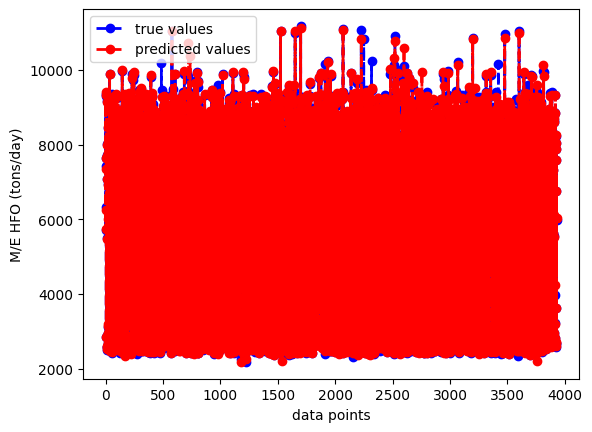

In [ ]:
x_axis = np.linspace(1, len(preds), num = len(preds), endpoint=True)
plt.plot(x_axis, y_test['M/E Brake Power (KW)'].values,color='blue', marker='o', linestyle='dashed',linewidth=2, label='true values')
plt.plot(x_axis, preds,color='red', marker='o', linestyle='dashed',linewidth=2, label='predicted values') #preds[:, 0]
plt.xlabel('data points')
plt.ylabel('M/E HFO (tons/day)')
plt.legend()
plt.show()

#**Comparison Data**

In [ ]:
data = pd.read_excel('KIMOLOS analysis from DD till 9-1-2024.xlsx', sheet_name=1)

In [ ]:
data['UTC Time'] = pd.to_datetime(data['UTC Time'])
data['Mean Draft (m)'] = (data['DRAFT MP'] + data['DRAFT MS'])/2
data['Course Drift (deg)'] = data['Gyro Heading (deg)'] - data['GPS Course (deg)']

wanted_col = data.select_dtypes(include=[float]).columns

for col in wanted_col:
  data = data.loc[(np.abs(stats.zscore(data[col])) < 2.7)]

data = data.loc[data["Voyage Status"].str.contains('Sailing')\
                          & (data["M/E FLOW METER GROUP ALARM"] != 1)\
                          & (data["M/E RPM"] > 0)\
                          & (data["M/E Brake Power (KW)"] > 2000)\
                          #& (data["Depth (m)"] > 70)\
                          & (data["SOW (knots)"] >= 5)\
                          & (data["SOG (knots)"] >= 5)\
                          & (data["M/E FOC (tons/day)"] > 0)\
                          ]

#y = data.loc[:, ['M/E FOC (tons/day)', 'M/E Brake Power (KW)', 'M/E RPM']] # .apply(lambda iterator: ((iterator - iterator.mean())/iterator.std()).round(2))

####
"""
foc_mean = np.mean(y['M/E FOC (tons/day)'])
power_mean = np.mean(y['M/E Brake Power (KW)'])
rpm_mean = np.mean(y['M/E RPM'])

foc_std = np.std(y['M/E FOC (tons/day)'])
power_std = np.std(y['M/E Brake Power (KW)'])
rpm_std = np.std(y['M/E RPM'])
"""
x = data.drop(['UTC Time', 'Voyage Status', 'M/E FLOW METER GROUP ALARM', \
                   'Loading Status', 'M/E FOC (tons/day)', 'M/E Brake Power (KW)', \
               'Voyage No', 'M/E Fuel Type', 'Steady/Transient Operation'], axis=1)#.apply(lambda iterator: ((iterator - iterator.mean())/iterator.std()))
y = data.loc[:, ['M/E Brake Power (KW)']]

"""
y['M/E FOC (tons/day)'] = (y['M/E FOC (tons/day)'] - foc_mean)/foc_std
y['M/E Brake Power (KW)'] = (y['M/E Brake Power (KW)'] - power_mean)/power_std
y['M/E RPM'] = (y['M/E RPM'] - rpm_mean)/rpm_std
"""

"\ny['M/E FOC (tons/day)'] = (y['M/E FOC (tons/day)'] - foc_mean)/foc_std\ny['M/E Brake Power (KW)'] = (y['M/E Brake Power (KW)'] - power_mean)/power_std\ny['M/E RPM'] = (y['M/E RPM'] - rpm_mean)/rpm_std\n"

In [ ]:
#saved_model = load_model('best_model.h5')

#preds = saved_model.predict(x)

preds = xgb.DMatrix(x)
preds = model.predict(preds)

#preds = Gmodel.predict(x)

MAE_metric = mean_absolute_error(y, preds) #preds[:, 0]
MSE_metric = mean_squared_error(y, preds) #preds[:, 0]
R2_metric = r2_score(y, preds) #preds[:, 0]
Labels_metric = 'LSTM'

print('The model ANN has a MAE of {}'.format(mean_absolute_error(y, preds)), 'and an R-square score of {}'.format(r2_score(y, preds))) #preds[:, 0]

The model ANN has a MAE of 451.25162640678354 and an R-square score of 0.931659552553127


In [ ]:
data['optimal Brake Power (KW)'] = preds

In [ ]:
ship_data_Ba = pd.DataFrame(columns=['SOW (knots)', 'latest Brake Power (KW)', 'optimal Brake Power (KW)'])


for i in range(6, 15, 1):
  ship_data_Ba.loc[len(ship_data_Ba.index)] = data[['SOW (knots)', 'M/E Brake Power (KW)', 'optimal Brake Power (KW)']].loc[(data["SOW (knots)"] < (i+0.5)) & (data["SOW (knots)"] > (i-0.5))].mean(axis=0).values

ship_data_Ba.dropna(axis=0, inplace=True)
ship_data_Ba.reset_index(drop=True, inplace=True)
ship_data_Ba.head(20)

,SOW (knots),latest Brake Power (KW),optimal Brake Power (KW)
0,6.017500,2370.227500,2208.491211
1,7.096667,3829.430000,3382.595459
2,8.000000,4420.621429,4325.028320
3,9.326384,2886.600982,2844.549561
4,9.867312,3381.906492,3300.826904
5,10.989332,5066.651985,4788.395508
6,12.109955,6548.875642,6165.172852
7,12.970626,8017.586764,7560.229492
8,14.002217,8867.653048,8381.777344


<function matplotlib.pyplot.show(close=None, block=None)>

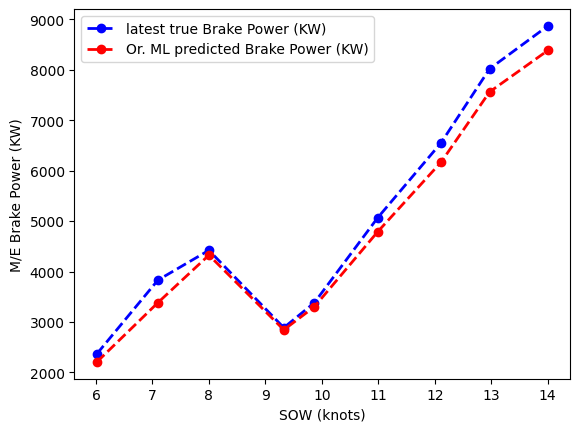

In [ ]:
plt.plot(ship_data_Ba["SOW (knots)"], ship_data_Ba["latest Brake Power (KW)"],color='blue', marker='o', linestyle='dashed',linewidth=2, label='latest true Brake Power (KW)')
plt.plot(ship_data_Ba["SOW (knots)"], ship_data_Ba["optimal Brake Power (KW)"],color='red', marker='o', linestyle='dashed',linewidth=2, label='Or. ML predicted Brake Power (KW)')
plt.xlabel('SOW (knots)')
plt.ylabel('M/E Brake Power (KW)')
plt.legend()
plt.show

In [ ]:
sample_data = data[['SOW (knots)', 'M/E Brake Power (KW)', 'optimal Brake Power (KW)']].loc[data["Voyage Status"].str.contains('Sailing')\
                          & (data["M/E FLOW METER GROUP ALARM"] != 1)\
                          & (data["SOW (knots)"] > 5)\
                          & (data["M/E RPM"] > 0)\
                          #& (ship_data["Depth ISO Criteria"] > 0)\
                          & data["Loading Status"].str.contains('LADEN')\
                          & (data['Sea Currents Speed (knots)'] < 1)\
                          & (data['Wind Force (BF)'] < 5)\
                          & (data["M/E Fuel Type"].str.contains('HFO'))\
                          #& (np.abs(stats.zscore(ship_data['Mean Draft (m)'])) < 2.7)\
                          & (data["Steady/Transient Operation"].str.contains('Steady State'))] #.sample(n = 100)
sample_data.sort_values(by=['SOW (knots)'], ascending=False, inplace = True)

<function matplotlib.pyplot.show(close=None, block=None)>

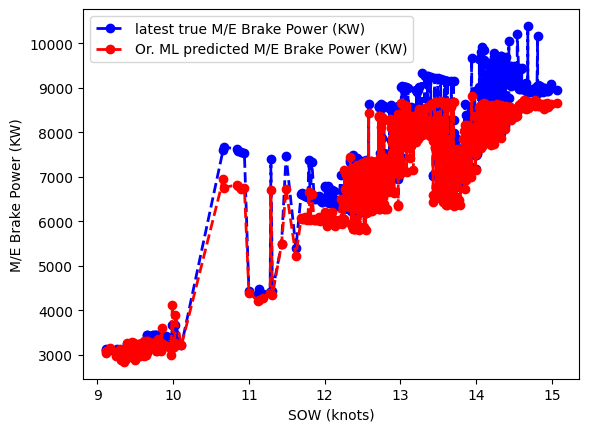

In [ ]:
plt.plot(sample_data["SOW (knots)"], sample_data["M/E Brake Power (KW)"],color='blue', marker='o', linestyle='dashed',linewidth=2, label='latest true M/E Brake Power (KW)')
plt.plot(sample_data["SOW (knots)"], sample_data["optimal Brake Power (KW)"],color='red', marker='o', linestyle='dashed',linewidth=2, label='Or. ML predicted M/E Brake Power (KW)')
plt.xlabel('SOW (knots)')
plt.ylabel('M/E Brake Power (KW)')
plt.legend()
plt.show

In [ ]:
def interpol_func(x, a, b):
    return a*x**b

In [ ]:
data2 = pd.read_excel('FOLEGANDROS Silicon Performance LADEN at 14-11-2023.xlsx', sheet_name=2)

data2['UTC Time'] = pd.to_datetime(data2['UTC Time'])
data2['Mean Draft (m)'] = (data2['DRAFT MP'] + data2['DRAFT MS'])/2
data2['Course Drift (deg)'] = data2['Gyro Heading (deg)'] - data2['GPS Course (deg)']

wanted_col = data2.select_dtypes(include=[float]).columns

for col in wanted_col:
  data2 = data2.loc[(np.abs(stats.zscore(data2[col])) < 2.7)]

data2 = data2.loc[data2["Voyage Status"].str.contains('Sailing')\
                          & (data2["M/E FLOW METER GROUP ALARM"] != 1)\
                          & (data2["M/E RPM"] > 0)\
                          & (data2["M/E Brake Power (KW)"] > 2000)\
                          #& (data["Depth (m)"] > 70)\
                          & (data2["SOW (knots)"] >= 5)\
                          & (data2["SOG (knots)"] >= 5)\
                          & (data2["M/E FOC (tons/day)"] > 0)\
                          ]

y = data2.loc[:, ['M/E FOC (tons/day)', 'M/E Brake Power (KW)', 'M/E RPM']] # .apply(lambda iterator: ((iterator - iterator.mean())/iterator.std()).round(2))

####

foc_mean = np.mean(y['M/E FOC (tons/day)'])
power_mean = np.mean(y['M/E Brake Power (KW)'])
rpm_mean = np.mean(y['M/E RPM'])

foc_std = np.std(y['M/E FOC (tons/day)'])
power_std = np.std(y['M/E Brake Power (KW)'])
rpm_std = np.std(y['M/E RPM'])

x = data2.drop(['UTC Time', 'Voyage Status', 'M/E FLOW METER GROUP ALARM', \
                   'Loading Status', 'M/E FOC (tons/day)', 'M/E Brake Power (KW)', \
               'Voyage No', 'M/E Fuel Type', 'Steady/Transient Operation'], axis=1)#.apply(lambda iterator: ((iterator - iterator.mean())/iterator.std()))
y = data2.loc[:, ['M/E FOC (tons/day)']]

"""
y['M/E FOC (tons/day)'] = (y['M/E FOC (tons/day)'] - foc_mean)/foc_std
y['M/E Brake Power (KW)'] = (y['M/E Brake Power (KW)'] - power_mean)/power_std
y['M/E RPM'] = (y['M/E RPM'] - rpm_mean)/rpm_std

"""

FileNotFoundError: [Errno 2] No such file or directory: 'FOLEGANDROS Silicon Performance LADEN at 14-11-2023.xlsx'

In [ ]:
sample_data2 = data2[['SOW (knots)', 'M/E FOC (tons/day)']].loc[data2["Voyage Status"].str.contains('Sailing')\
                          & (data2["M/E FLOW METER GROUP ALARM"] != 1)\
                          & (data2["SOW (knots)"] > 5)\
                          & (data2["M/E RPM"] > 0)\
                          #& (ship_data["Depth ISO Criteria"] > 0)\
                          & data2["Loading Status"].str.contains('LADEN')\
                          & (data2['Sea Currents Speed (knots)'] < 1.25)\
                          & (data2['Wind Force (BF)'] < 5)\
                          & (data2["M/E Fuel Type"].str.contains('HFO'))\
                          #& (np.abs(stats.zscore(data2['Mean Draft (m)'])) < 2.7)\
                          & (data2["Steady/Transient Operation"].str.contains('Steady State'))] #.sample(n = 100)
sample_data2.sort_values(by=['SOW (knots)'], ascending=False, inplace = True)

In [ ]:
sample_data2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4187 entries, 471 to 9613
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SOW (knots)         4187 non-null   float64
 1   M/E FOC (tons/day)  4187 non-null   float64
dtypes: float64(2)
memory usage: 98.1 KB


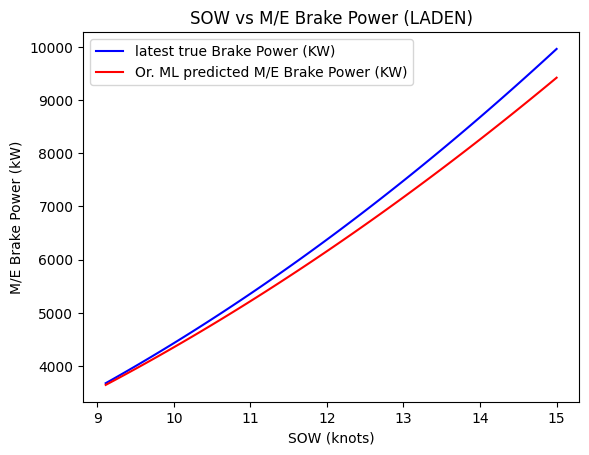

In [ ]:
#alpha_latest = sci.optimize.curve_fit(interpol_func, xdata=sample_data2["SOW (knots)"], ydata=sample_data2["M/E FOC (tons/day)"])
alpha_Real, _ = sci.optimize.curve_fit(interpol_func, xdata=sample_data["SOW (knots)"], ydata=sample_data["M/E Brake Power (KW)"])
alpha_Opt, _ = sci.optimize.curve_fit(interpol_func, xdata=sample_data["SOW (knots)"], ydata=sample_data["optimal Brake Power (KW)"])
#plt.plot(sample_data["SOW (knots)"], sample_data["M/E FOC (tons/day)"],color='blue', marker='o', linestyle='dashed',linewidth=2, label='latest M/E FOC')
#plt.plot(sample_data["SOW (knots)"], sample_data["optimal M/E FOC (tons/day)"],color='red', marker='o', linestyle='dashed',linewidth=2, label='optimal M/E FOC')
"""
x_range_latest = np.arange(min(sample_data2["SOW (knots)"]), max(sample_data2["SOW (knots)"]), (max(sample_data2["SOW (knots)"]) - min(sample_data2["SOW (knots)"]))/100)

y_range_latest = interpol_func(x_range_latest, alpha_latest[0][0], alpha_latest[0][1])

plt.plot(x_range_latest, y_range_latest, color='green', label='before DD true M/E FOC')
"""
###

x_range_real = np.arange(min(sample_data["SOW (knots)"]), max(sample_data["SOW (knots)"]), (max(sample_data["SOW (knots)"]) - min(sample_data["SOW (knots)"]))/100)

y_range_real = interpol_func(x_range_real, alpha_Real[0], alpha_Real[1])

plt.plot(x_range_real, y_range_real, color='blue', label='latest true Brake Power (KW)')

###

x_range_opt = np.arange(min(sample_data["SOW (knots)"]), max(sample_data["SOW (knots)"]), (max(sample_data["SOW (knots)"]) - min(sample_data["SOW (knots)"]))/100)

y_range_opt = interpol_func(x_range_opt, alpha_Opt[0], alpha_Opt[1])

plt.plot(x_range_opt, y_range_opt, color='red', label='Or. ML predicted M/E Brake Power (KW)')

plt.xlabel("SOW (knots)")
plt.ylabel("M/E Brake Power (kW)")
plt.title("SOW vs M/E Brake Power (LADEN)")
plt.legend()
plt.show()